# Marketplace Safety - Prioritization of Suspicious Listings and Messages

**Background**  
This project was carried out on behalf of the analytics team at a company that operates a 
marketplace app, similar to Blocket. The platform is used daily by a large number of users, the vast majority of whom are genuine. However, every week a small proportion of problematic activity occurs: scam listings, spam, suspicious accounts acting quickly, and attempts to move conversations off the platform.

**Problem**  
The company's Trust & Safety team manually reviews and handles suspicious content. The problem is that the volume is too large for the team to review everything in time. Management is therefore requesting a decision-support tool that helps the team prioritize what to review first.

**Goal**  
The goal is to deliver a solution that:
- performs reasonably well on new, unseen data
- can be run regularly in production
- can be explained to non-technical stakeholders

The focus is on prioritization and decision support.

**Stakeholder**  
The COO sees 2 costs:
- the time required to check the cases
- the missed scams

Kolumnnamn | Förklaring |
|---|---|
| `id` | Unikt identifieringsnummer för varje post |
| `day` | Dagen då händelsen inträffade |
| `event_type` | Typ av händelse (t.ex. visning, meddelande, anmälan) |
| `category` | Produktkategori för annonsen |
| `region` | Geografiskt område där annonsen publicerades |
| `device` | Enhetstyp som användes (t.ex. mobil, dator) |
| `account_age_days` | Antal dagar sedan kontot skapades |
| `num_prev_listings` | Antal tidigare annonser från samma användare |
| `prev_reports_30d` | Antal gånger användaren anmälts de senaste 30 dagarna |
| `verification_level` | Verifieringsnivå för kontot |
| `price` | Annonsens pris |
| `num_images` | Antal bilder i annonsen |
| `message_length` | Längden på meddelandet i annonsen |
| `contains_off_platform` | Om användaren försökt flytta konversationen utanför plattformen |
| `urgency_words` | Om annonsen innehåller ord som skapar artificiell brådska |
| `payment_attempt` | Om ett betalningsförsök har skett |
| `time_to_first_response_min` | Tid i minuter till första svar |
| `is_suspicious` | Målvariabel — om annonsen är misstänkt (1) eller inte (0) |

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, 
    cross_val_predict,
    cross_val_score, 
    GridSearchCV, 
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from joblib import dump, load

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier


from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(palette="rocket")

### Data understanding & EDA

- Showing dataset size, data types and statistics
- Checking for missing values 
- Showing target distribution of the target
- Checking correlation among numeric variables

In [2]:
marketplace_data = pd.read_csv("../Data/historical_data.csv")

print(marketplace_data.shape)
marketplace_data.head()

(12000, 18)


,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [3]:
marketplace_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,12000.0,5999.500000,3464.245950,0.00,2999.750,5999.500,8999.250,11999.00
day,12000.0,7.482667,4.032520,1.00,4.000,7.000,11.000,14.00
account_age_days,12000.0,99.632567,112.903541,2.20,36.300,66.600,120.700,2741.70
num_prev_listings,12000.0,3.027750,1.766467,0.00,2.000,3.000,4.000,12.00
prev_reports_30d,12000.0,0.151500,0.386083,0.00,0.000,0.000,0.000,3.00
verification_level,12000.0,0.710167,0.719171,0.00,0.000,1.000,1.000,2.00
price,11182.0,207.348603,196.226023,7.67,86.195,149.225,256.795,2743.08
num_images,12000.0,2.870417,1.766886,0.00,2.000,3.000,4.000,10.00
message_length,12000.0,111.154417,66.396885,0.00,63.000,108.000,155.000,416.00
contains_off_platform,12000.0,0.072833,0.259874,0.00,0.000,0.000,0.000,1.00


In [4]:
marketplace_data.dtypes

id                              int64
day                             int64
event_type                        str
category                          str
region                            str
device                            str
account_age_days              float64
num_prev_listings               int64
prev_reports_30d                int64
verification_level              int64
price                         float64
num_images                      int64
message_length                  int64
contains_off_platform           int64
urgency_words                   int64
payment_attempt                 int64
time_to_first_response_min    float64
is_suspicious                   int64
dtype: object

In [5]:
print("Total missing values:\n\n", marketplace_data.isna().sum())
print("\n")
print("Percentage of missing values:\n\n", round(marketplace_data.isnull().sum() / len(marketplace_data) * 100),3)

Total missing values:

 id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64


Percentage of missing values:

 id                            0.0
day                           0.0
event_type                    0.0
category                      0.0
region                        3.0
device                        0.0
account_age_days              0.0
num_prev_listings             0.0
prev_reports_30d              0.0
verificatio

In [6]:
X_full = marketplace_data.drop(["is_suspicious"], axis=1)
y_full = marketplace_data["is_suspicious"]

print("X:", X_full.shape, "\ny:", y_full.shape)

X: (12000, 17) 
y: (12000,)


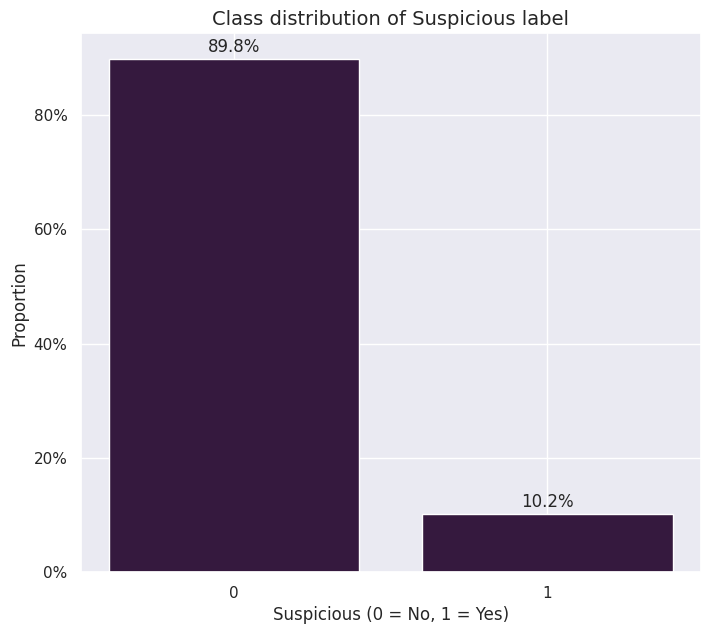

In [7]:
y_distribution = y_full.value_counts(normalize=True)

fig1, ax = plt.subplots(figsize=(8,7))
suspocious_distribution = ax.bar(y_distribution.index, y_distribution.values)

for bar in suspocious_distribution:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
            f'{height:.1%}', ha='center', va='bottom')

ax.set_title("Class distribution of Suspicious label", fontsize=14)
ax.set_xlabel("Suspicious (0 = No, 1 = Yes)")
ax.set_ylabel("Proportion")
ax.set_xticks([0, 1])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.savefig("../Img/1_suspicious_share")
plt.show()

In [8]:
correlation_with_target = marketplace_data.copy()

correlation_with_target = (
    correlation_with_target.drop(
        ["event_type", "category", "region", "device"], axis=1)
        .corr()["is_suspicious"]
        .sort_values(ascending=False)
)

display(correlation_with_target)

is_suspicious                 1.000000
contains_off_platform         0.141828
prev_reports_30d              0.130920
urgency_words                 0.087295
payment_attempt               0.066666
price                         0.011883
num_images                    0.009446
id                            0.005236
day                          -0.007565
message_length               -0.011989
time_to_first_response_min   -0.013942
num_prev_listings            -0.015895
verification_level           -0.100409
account_age_days             -0.103146
Name: is_suspicious, dtype: float64

### Train/test + preprocessing

- Created a train/test split of the data
- Built a pipeline where preprocessing is done in a way that prevents test data from influencing training (avoid leakage).
- For classification: use stratified split so classes are distributed reasonably.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("\n")
print(f"Classification train: \n{y_train.value_counts(normalize=True)}")
print("\n")
print(f"Classification test: \n{y_test.value_counts(normalize=True)}")

Train: (9600, 17) (9600,)
Test: (2400, 17) (2400,)


Classification train: 
is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64


Classification test: 
is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64


In [10]:
def engineer_features(X):
    X = X.copy()
    X["report_rate"] = X["prev_reports_30d"] / (X["num_prev_listings"] + 1)
    X["risk_score"]  = X["contains_off_platform"] + X["urgency_words"] + X["payment_attempt"]
    X["new_and_reported"] = ((X["account_age_days"] < 30) & (X["prev_reports_30d"] > 0)).astype(int)

    return X

feature_engineer = FunctionTransformer(engineer_features)

In [11]:
numeric_features_base = [
    "account_age_days", "num_prev_listings", "prev_reports_30d",
    "price", "num_images", "message_length", "verification_level",
    "time_to_first_response_min", "payment_attempt",
    "contains_off_platform", "urgency_words"
]

numeric_features_engineered = numeric_features_base + ["report_rate", "risk_score", "new_and_reported"]

categorical_features = ["event_type", "category", "region", "device"]

In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [13]:
preprocess_none = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_base),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

preprocess_engineered = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_engineered),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [14]:
basic_features_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_none),
    ("classifier", RandomForestClassifier(
        class_weight="balanced", n_estimators=200,
        min_samples_leaf=5, max_depth=10, random_state=42))
])

with_engineered_features_pipeline = Pipeline(steps=[
    ("features",   FunctionTransformer(engineer_features)),
    ("preprocess", preprocess_engineered),
    ("classifier", RandomForestClassifier(
        class_weight="balanced", n_estimators=200,
        min_samples_leaf=5, max_depth=10, random_state=42))
])

In [15]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

results_base = cross_validate(basic_features_pipeline, X_train, y_train, cv=5, scoring=scoring)
results_engineered = cross_validate(with_engineered_features_pipeline, X_train, y_train, cv=5, scoring=scoring)

rows = []
for metric in scoring:
    base = results_base[f"test_{metric}"].mean()
    eng  = results_engineered[f"test_{metric}"].mean()
    rows.append({"Metric": metric, "Base": round(base, 4), "Engineered": round(eng, 4), "Difference": round(eng - base, 4)})

pd.DataFrame(rows).set_index("Metric")

,Base,Engineered,Difference
Metric,,,
accuracy,0.8224,0.8290,0.0066
precision,0.2566,0.2711,0.0145
recall,0.3892,0.4004,0.0112
f1,0.3091,0.3232,0.0140
roc_auc,0.7405,0.7472,0.0066


3) Modeling and comparison

- Create a baseline.
- Train at least two additional models (at least 3 total including baseline).
- Evaluate with a reasonable method (e.g. cross-validation on train or a clear validation setup).
- Choose a metric and justify the choice based on your requirements card.
(Example models: LogisticRegression, DecisionTree, RandomForest, GradientBoosting…)

In [16]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced", min_samples_leaf=5, max_depth=10),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
}

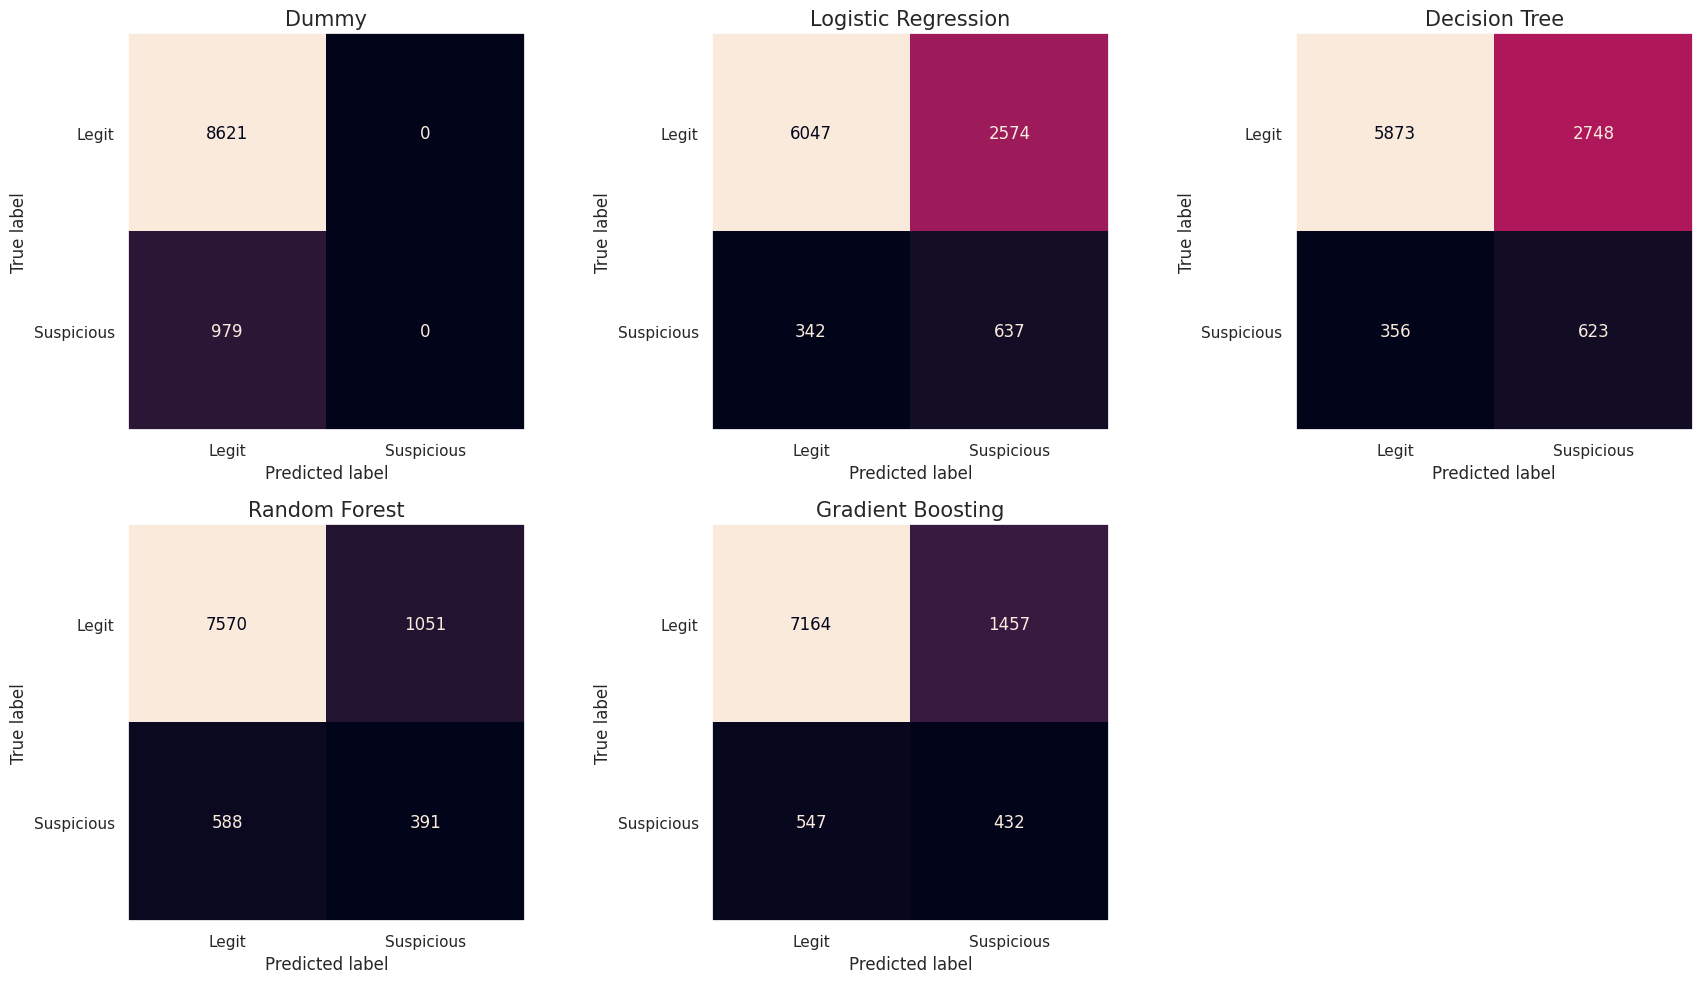

,model,accuracy,precision,recall,f1,roc_auc
3,Random Forest,0.829271,0.271151,0.399387,0.323007,0.746928
1,Logistic Regression,0.696250,0.198381,0.650664,0.304057,0.738979
4,Gradient Boosting,0.791250,0.228692,0.441267,0.301255,0.720598
2,Decision Tree,0.676667,0.184812,0.636364,0.286437,0.715378
0,Dummy,0.898021,0.000000,0.000000,0.000000,0.500000


In [17]:
# Building one pipeline for each model
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("feature_engineer", feature_engineer),
        ("preprocessor", preprocess_engineered),
        ("classifier", model)
    ])

# Evaluating each model with cross_val_predict and showing the confusion matrix for each model
rows = []

fig2, axes = plt.subplots(2, 3, figsize=(18,10))
axes_flat = axes.flatten()
axes_flat[5].set_visible(False)

for idx, (name, pipeline) in enumerate (pipelines.items()):
    y_pred = cross_val_predict(pipeline, X_train, y_train, cv=5, n_jobs=-1)

    y_proba = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        cv=5,
        n_jobs=-1,
        method="predict_proba"
    )[:, 1]

    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_train, y_pred),
        "precision": precision_score(y_train, y_pred, zero_division=0),
        "recall": recall_score(y_train, y_pred, zero_division=0),
        "f1": f1_score(y_train, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_train, y_proba)
    })

    cm = confusion_matrix(y_train, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Suspicious"])
    disp.plot(ax=axes_flat[idx], colorbar=False, cmap="rocket")
    axes_flat[idx].grid(False)
    axes_flat[idx].set_title(name, size=15)

plt.tight_layout()
plt.savefig("../Img/fig2_conf_matrix_all_models")
plt.show()

results_cv = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(results_cv)

The models' relatively low F1 score should be interpreted in the context of the dataset's characteristics. The data is synthetic so the boundaries between suspicious and legitimate listings are less sharp than in real-world data.  

The class imbalance makes F1 harder to optimize but the ROC AUC of ~0.74 indicates that 2 models have genuine discriminative ability, correctly ranking a suspicious listing above a legitimate one ~74% of the time.  

4) Select and optimize ONE model (hyperparameter tuning)

- Select a "final" model based on the comparison.
- Tune the selected model (small grid, at least 1–2 parameters).
- Briefly explain what you optimized and why (connect to the requirements card).

In [18]:
logreg_params = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs", "saga"]
}

rf_params = {
    "classifier__max_depth": [5, 10, 15],
    "classifier__min_samples_leaf": [3, 5, 10],
    "classifier__n_estimators": [100, 200, 300]
}

logreg_search = GridSearchCV(pipelines["Logistic Regression"], logreg_params, cv=5, scoring="f1")
rf_search = GridSearchCV(pipelines["Random Forest"], rf_params, cv=5, scoring="f1")

logreg_search.fit(X_train, y_train)
rf_search.fit(X_train, y_train)

print("Best LogReg F1:", logreg_search.best_score_, logreg_search.best_params_)
print("Best RF F1:", rf_search.best_score_, rf_search.best_params_)

Best LogReg F1: 0.30917859287100063 {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best RF F1: 0.3292995966337017 {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 300}


### Hyperparameter Tuning

To ensure a fair model comparison, both Logistic Regression and Random Forest were tuned using `GridSearchCV` with 5-fold cross-validation, optimizing for F1 score.

**Logistic Regression** was searched over regularization strength (`C`), penalty type (`l1/l2`) and solver. The best configuration used `C=0.1` with L1 regularization, indicating that a simpler, more constrained model performs better on this dataset.  
Best F1: **0.309**.

**Random Forest** was searched over tree depth (`max_depth`), minimum samples per leaf (`min_samples_leaf`), and number of trees (`n_estimators`). The best configuration used `max_depth=10`, `min_samples_leaf=10`, and `n_estimators=300`, confirming that limiting tree complexity is essential for handling the class imbalance.  
Best F1: **0.329**.

Random Forest was selected as the final model based on its superior and consistent F1 score across all evaluation stages.

## 5) Threshold / prioritization (linked to the requirements card)
- You must decide how the model will be used in practice. Choose a strategy:

    A) Threshold decision — flag as suspicious if probability ≥ t. Justify t based on the requirements card and show consequences (FP/FN or precision/recall) 
    
    B) Top-X prioritization — flag the X% highest risk (e.g. top 5% or top 50 per day). Justify X based on the requirements card and show consequences.

You must clearly show how your choice affects FP/FN and why it suits your stakeholder.

6) Deploy test: new data (Tuesday course week 6)
When you receive new_data.csv you should:

- use your locked pipeline
- create predictions and a priority list